# **Homework \#1**
### Author: Skyler Ruiter
### Date: September 10, 2025
### Course: Deep Learning Systems (ENGR-E 533)

---

#### Setup:

Load the needed modules and setup / verify the device torch detects

In [2]:
import torch
from torch.utils.data import DataLoader
import torchvision
import numpy as np
import time
import matplotlib.pyplot as plt

print(torch.cuda.is_available())
device=torch.device('cuda')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(device)

True
cuda


Download the MNIST training and testing datasets. Normalize them and turn them into tensors. Then use the DataLoader to batch the data and optimize the workflow with pinned memory, prefetching, and batch sizes. Verify the shape of the data.

In [3]:
mnist_train = torchvision.datasets.MNIST('mnist',
                                         train=True,
                                         download=True,
                                         transform=torchvision.transforms.Compose([
                                             torchvision.transforms.ToTensor(),
                                             torchvision.transforms.Normalize((0.1307,), (0.3081,))
                                         ]))
mnist_test = torchvision.datasets.MNIST('mnist',
                                        train=False,
                                        download=True,
                                        transform=torchvision.transforms.Compose([
                                            torchvision.transforms.ToTensor(),
                                            torchvision.transforms.Normalize((0.1307,), (0.3081,))
                                        ]))

X_train, y_train = mnist_train.data, mnist_train.targets
X_test, y_test = mnist_test.data, mnist_test.targets

X_train = X_train.float()
X_test = X_test.float()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = (X_train - 0.1307) / 0.3081
X_test = (X_test - 0.1307) / 0.3081

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

train_dataloader = DataLoader(mnist_train, batch_size=128, num_workers=4, pin_memory=True, shuffle=True)
test_dataloader = DataLoader(mnist_test, batch_size=128, num_workers=4, pin_memory=True, shuffle=True)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Test data shape: {X_test.shape}, {y_test.shape}")

Training data shape: torch.Size([60000, 28, 28]), torch.Size([60000])
Test data shape: torch.Size([10000, 28, 28]), torch.Size([10000])


---

#### Question 1: Softmax MNIST Classification

Created a simple torch NN model for with only the softmax regression. 

Uses cross entropy loss and SGD to optimize.

Also defines the methods for training and testing NNs

In [4]:
class SoftmaxRegression(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = torch.nn.Flatten()
    self.linear = torch.nn.Linear(28*28, 10)
    
  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear(x)
    return logits

model = SoftmaxRegression().to(device)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

In [5]:
def train(dataloader, model, loss_fn, optimizer):
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    
    # prediction error
    pred = model(X)
    loss = loss_fn(pred, y)
    
    # backprop
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

def test(dataloader, model, loss_fn):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  model.eval()
  test_loss, correct = 0, 0
  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()
  test_loss /= num_batches
  correct /= size
  return correct

In [6]:
def train_direct(X, y, model, loss_fn, optimizer):
  model.train()
  
  pred = model(X)
  loss = loss_fn(pred, y)
  
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

def test_direct(X, y, model, loss_fn):
  model.eval()
  correct = 0
  with torch.no_grad():
    pred = model(X)
    correct = (pred.argmax(1) == y).type(torch.float).sum().item()
  return correct / len(y)

Function to visualize the weight matrices to see the features being learned

In [7]:
def plot_weights(model, epoch):
  weights = model.linear.weight.detach().cpu().numpy()
  fig, axes = plt.subplots(1, 10, figsize=(15, 2))
  for i in range(10):
    axes[i].imshow(weights[i].reshape(28, 28), cmap='seismic')
    axes[i].axis('off')
  plt.suptitle(f'Weights after epoch {epoch}')
  plt.show()

Trains the softmax regression network that doesn't learn a latent space. Uses 200 epochs and stores the test accuracy at each epoch. 

Displays the weights after 20 and 200 epochs. Then plots the test accuracy over the epochs.

* The weights after 20 epochs show some structure but are quite noisy. After 200 the weights gain a slight amount more definition.

* The plot shows that the model quickly converges to ~92% accuracy by 100 epochs and stays there.

Epoch 1
Epoch 11


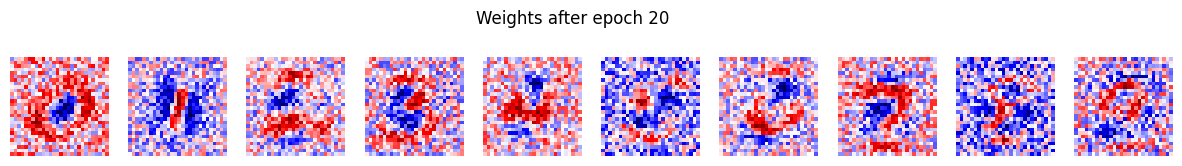

Epoch 21
Epoch 31
Epoch 41
Epoch 51
Epoch 61
Epoch 71
Epoch 81
Epoch 91
Epoch 101
Epoch 111
Epoch 121
Epoch 131
Epoch 141
Epoch 151
Epoch 161
Epoch 171
Epoch 181
Epoch 191


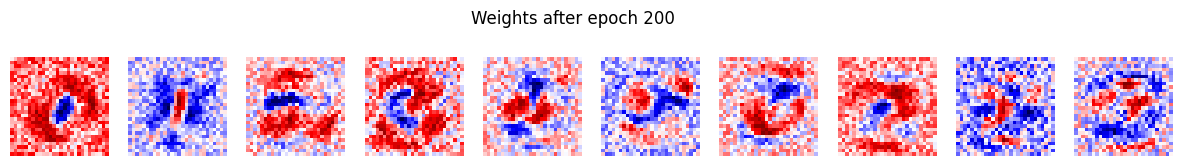

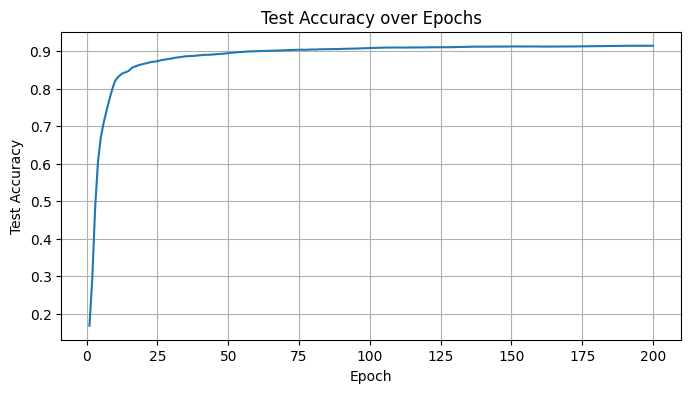

In [8]:
test_accuracies = []

epochs = 200
for t in range(epochs):
  if t % 10 == 0:
    print(f"Epoch {t+1}")
  train_direct(X_train, y_train, model, loss_fn, optimizer)
  acc = test_direct(X_test, y_test, model, loss_fn)
  test_accuracies.append(acc)
  
  if t+1 == 20 or t+1 == 200:
    plot_weights(model, t+1)

plt.figure(figsize=(8,4))
plt.plot(range(1, epochs+1), test_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy over Epochs")
plt.grid(True)
plt.show()

---

#### Question 2: Autoencoders

In [204]:
test_accuracies_naive = []
test_accuracies_sparse = []

Class for the Naive Autoencoder implementation. Uses a hidden dimension of 100 and a single hidden layer. 

Uses Sigmoid as the non-linear activation function.

Also defines methods for testing and training the Autoencoder.

In [205]:
class AutoencoderNaive(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = torch.nn.Flatten()
    self.encoder = torch.nn.Sequential(
      torch.nn.Linear(784, 100),
      torch.nn.Sigmoid()
    )
    self.decoder = torch.nn.Linear(100, 784)
  def forward(self, x):
    x = self.flatten(x)
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

def train_AE(dataloader, model, loss_fn, optimizer):
  model.train()
  for batch, (X, _) in enumerate(dataloader):
    X = X.to(device)
    
    X_reconstruct = model(X)
    loss = loss_fn(X_reconstruct, X.view(X.size(0), -1))
    
    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

def test_AE(dataloader, model, loss_fn):
  model.eval()
  test_loss = 0
  num_batches = len(dataloader)
  size = len(dataloader.dataset)
  with torch.no_grad():
    for X, _ in dataloader:
      X = X.to(device)      
      X_reconstruct = model(X)
      test_loss += loss_fn(X_reconstruct, X.view(X.size(0), -1)).item()
  test_loss /= num_batches
  return test_loss

Found a useful sparse autoencoder implementation online, which I adopted here.

We use the same Sigmoid non-linear activation function and model structure, but use the KL divergence with a sparsity target and sparsity lambda to encourage the model to learn more robust and meaningful features in the latent space.

Also adopts their training method.

In [206]:
# https://github.com/IParraMartin/Sparse-Autoencoder/blob/main/sae.py
class AutoEncoderSparse(torch.nn.Module):
  def __init__(self, sparsity_target=0.2, sparsity_lambda=0.1):
    super().__init__()
    self.flatten = torch.nn.Flatten()
    self.encoder = torch.nn.Sequential(
      torch.nn.Linear(784, 100),
      torch.nn.Sigmoid()
    )
    self.decoder = torch.nn.Linear(100, 784)
    self.sparsity_target = sparsity_target
    self.sparsity_lambda = sparsity_lambda
  def forward(self, x):
    x = self.flatten(x)
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return encoded, decoded
  def sparsity_penalty(self, encoded):
    rho_hat = torch.mean(encoded, dim=0)
    rho = self.sparsity_target
    epsilon = 1e-8
    rho_hat = torch.clamp(rho_hat, min=epsilon, max=1 - epsilon)
    kl_divergence = rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))
    sparsity_penalty = torch.sum(kl_divergence)
    return self.sparsity_lambda * sparsity_penalty
  def loss_function(self, x_hat, x, encoded):
    mse_loss = torch.nn.functional.mse_loss(x_hat, x)
    sparsity_loss = self.sparsity_penalty(encoded)
    return mse_loss + sparsity_loss
  
def train_AE_sparse(data_loader, model, optimizer, n_epochs):
  for epoch in range(n_epochs):
    total_loss = 0
    for data, _ in data_loader:
      data = data.view(data.size(0), -1).to(device)
      optimizer.zero_grad()
      encoded, decoded = model(data)
      loss = model.loss_function(decoded, data, encoded)
      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step()
      total_loss += loss.item()
    if epoch % 10 == 0:
      print(f"Epoch {epoch+1}, Loss: {total_loss/len(data_loader):.4f}")

  sample_data, _ = next(iter(data_loader))
  sample_data = sample_data.view(sample_data.size(0), -1).to(device)
  with torch.no_grad():
    activations, _ = model(sample_data)
  return activations.cpu().numpy(), sample_data.cpu().numpy()

In [407]:
def train_AE_direct(X, model, loss_fn, optimizer):
  model.train()
  
  X_flattened = X.view(X.size(0), -1)
  X_reconstruct = model(X)
  loss = loss_fn(X_reconstruct, X_flattened)
  
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  
  return loss.item()


def train_sparse_AE_direct(X, model, optimizer):
  model.train()
  X_flattened = X.view(X.size(0), -1)
  
  optimizer.zero_grad()
  encoded, decoded = model(X)
  loss = model.loss_function(decoded, X_flattened, encoded)
  loss.backward()
  torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
  optimizer.step()
  
  return loss.item()

In [222]:
def print_ae_results(model, dataloader, model_type="naive"):
    # Smaller figure and yellow-blue palette
    plt.figure(figsize=(8, 6))
    plt.suptitle("Learned Feature Templates", fontsize=16)

    # Get encoder weights (first layer)
    weights = model.encoder[0].weight.data.cpu().numpy()

    # Plot 25 templates in a 5x5 grid
    for i in range(25):
        plt.subplot(5, 5, i+1)
        plt.imshow(weights[i].reshape(28, 28), cmap='YlGnBu')
        plt.axis('off')
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

    # Reconstructed images (smaller)
    plt.figure(figsize=(10, 8))
    plt.suptitle("Reconstructed Images", fontsize=16)

    data_iter = iter(dataloader)
    images, _ = next(data_iter)
    images_subset = images[:25].to(device)

    with torch.no_grad():
        if model_type == "sparse":
            _, reconstructions = model(images_subset)
        else:
            reconstructions = model(images_subset)

    for i in range(25):
        plt.subplot(5, 5, i+1)
        plt.imshow(reconstructions[i].cpu().view(28, 28), cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

    # Hidden unit activations (unchanged, but smaller)
    plt.figure(figsize=(8, 6))
    plt.suptitle("Hidden Unit Activations (Latent Space)", fontsize=16)

    data_iter = iter(dataloader)
    images, _ = next(data_iter)
    images_subset = images[:150].to(device)

    with torch.no_grad():
        if model_type == "sparse":
            activations, _ = model(images_subset)
        else:
            activations = model.encoder(model.flatten(images_subset))

    act_slice = activations[:150, :100].cpu().numpy()
    plt.imshow(act_slice, cmap='YlGnBu', aspect='auto')
    plt.colorbar(label="Activation Value")
    plt.xlabel("Hidden Unit Index")
    plt.ylabel("Sample Index")
    plt.title(f"Hidden Activations Heatmap ({model_type.capitalize()} Autoencoder)")
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

Training the Naive and Sparse Autoencoders

* uses 200 epochs for training
* base loss uses MSE (w/ sparisty adding sparsity regularization)
* tried to use SGD pure but it was not converging, so I brought in some momentum
  * I also tried adam which worked amazingly but isn't what the assignment asked for

In [408]:
epochs = 200
naive_losses = []

naive_model = AutoencoderNaive().to(device)
naive_loss_fn = torch.nn.MSELoss()
naive_optimizer = torch.optim.SGD(naive_model.parameters(), lr=0.9, momentum=0.9)

In [409]:
sparse_losses = []

sparse_model = AutoEncoderSparse().to(device)
sparse_loss_fn = sparse_model.loss_function
sparse_optimizer = torch.optim.SGD(sparse_model.parameters(), lr=0.5, momentum=0.8)

In [410]:
for t in range(epochs):  
  loss = train_AE_direct(X_train, naive_model, naive_loss_fn, naive_optimizer)
  naive_losses.append(loss)
  
  if t % 10 == 0:
    print(f"Epoch {t+1}, Loss: {loss:.4f}")

for t in range(epochs):
  loss = train_sparse_AE_direct(X_train, sparse_model, sparse_optimizer)
  sparse_losses.append(loss)

  if t % 10 == 0:
    print(f"Epoch {t+1}, Sparse Loss: {loss:.4f}")

Epoch 1, Loss: 1.1058
Epoch 11, Loss: 0.7493
Epoch 21, Loss: 0.6493
Epoch 31, Loss: 0.5839
Epoch 41, Loss: 0.5232
Epoch 51, Loss: 0.4816
Epoch 61, Loss: 0.4490
Epoch 71, Loss: 0.4235
Epoch 81, Loss: 0.4023
Epoch 91, Loss: 0.3839
Epoch 101, Loss: 0.3679
Epoch 111, Loss: 0.3538
Epoch 121, Loss: 0.3412
Epoch 131, Loss: 0.3298
Epoch 141, Loss: 0.3195
Epoch 151, Loss: 0.3101
Epoch 161, Loss: 0.3016
Epoch 171, Loss: 0.2937
Epoch 181, Loss: 0.2864
Epoch 191, Loss: 0.2796
Epoch 1, Sparse Loss: 3.1871
Epoch 11, Sparse Loss: 0.9710
Epoch 21, Sparse Loss: 0.8500
Epoch 31, Sparse Loss: 0.7779
Epoch 41, Sparse Loss: 0.7244
Epoch 51, Sparse Loss: 0.6808
Epoch 61, Sparse Loss: 0.6453
Epoch 71, Sparse Loss: 0.6166
Epoch 81, Sparse Loss: 0.5928
Epoch 91, Sparse Loss: 0.5725
Epoch 101, Sparse Loss: 0.5548
Epoch 111, Sparse Loss: 0.5391
Epoch 121, Sparse Loss: 0.5249
Epoch 131, Sparse Loss: 0.5120
Epoch 141, Sparse Loss: 0.5004
Epoch 151, Sparse Loss: 0.4897
Epoch 161, Sparse Loss: 0.4799
Epoch 171, Spar

### Naive Autoencoder Results

The templates learned by the naive autoencoder are not easy to interpret, and appear to capture abstract pixel patterns rather than meaningful features like edges.

The reconstruction looked great after the full training process. And the latent space was very noisy, with little pattern or structure.

### Sparse Autoencoder Results

The templates learned by the sparse autoencoder on the other hand are much more robust looking. They appear to model the edges of the numbers or specific elements within the images. The reconstruction is a bit more blurry in comparison, but that is due to the sparisty constraint providing another element to optimize.

The latent space is more structured and very sparse to utilize the learned features from the encoder. 

Naive Autoencoder Results:


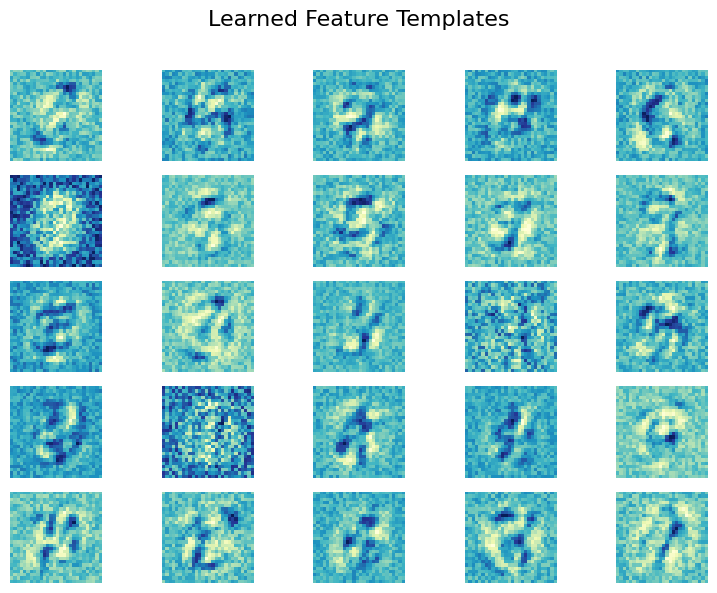

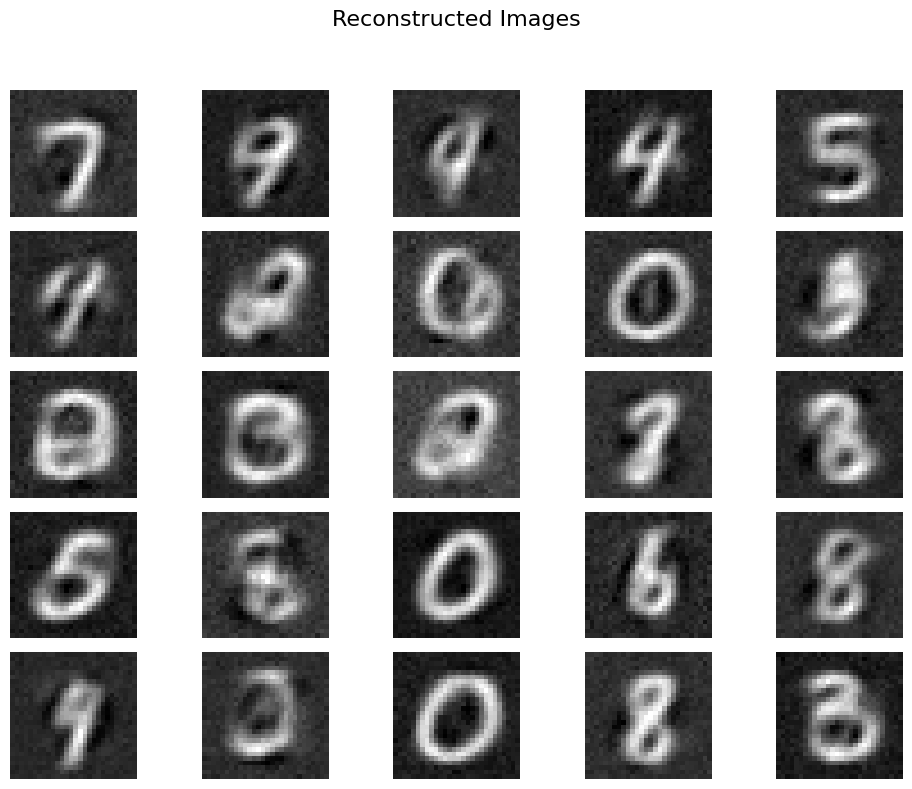

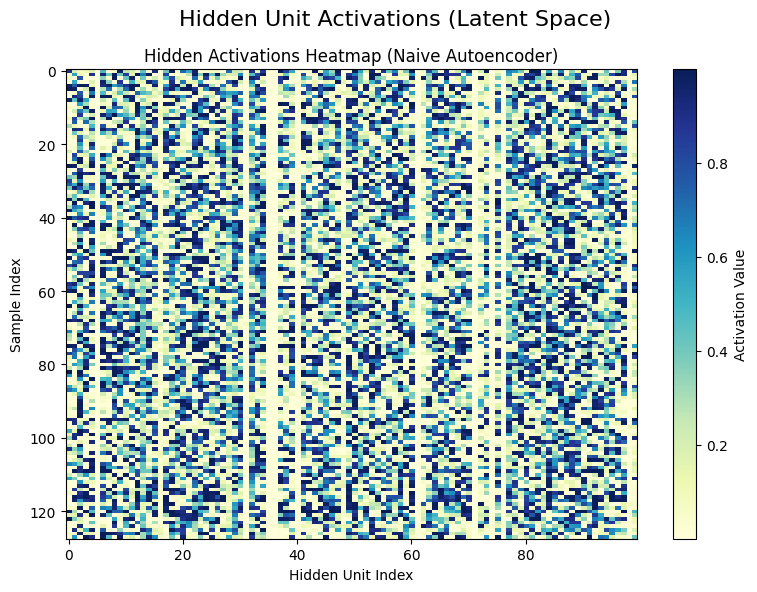


Sparse Autoencoder Results:


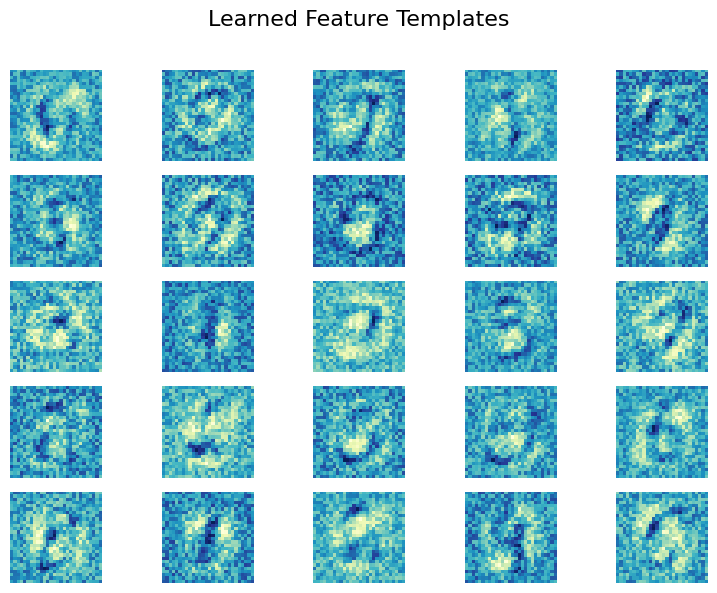

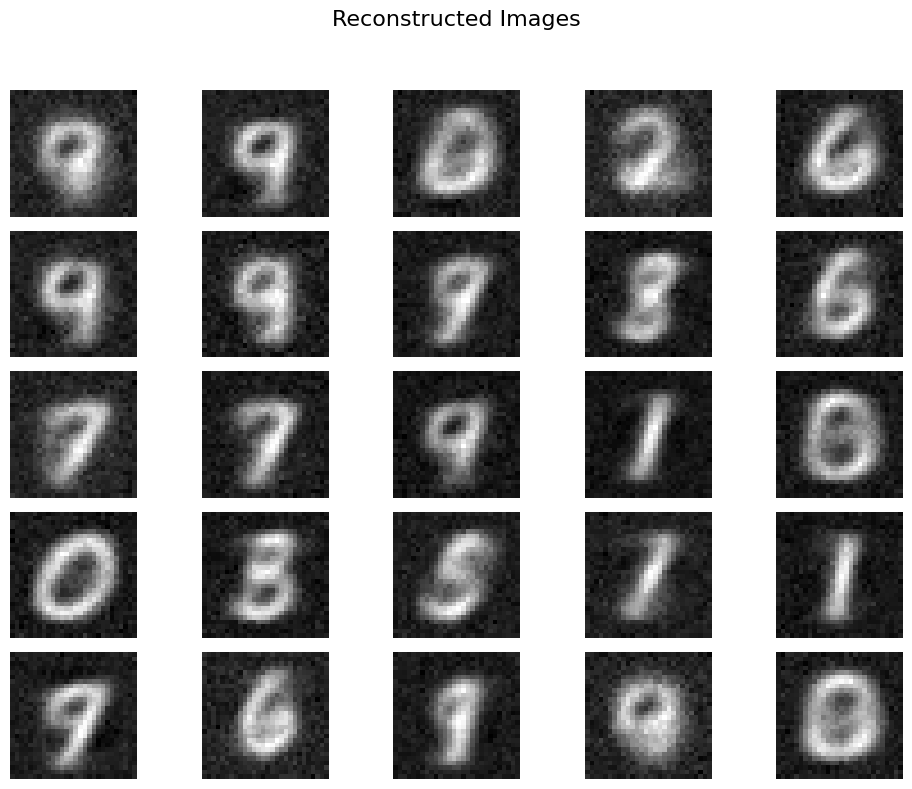

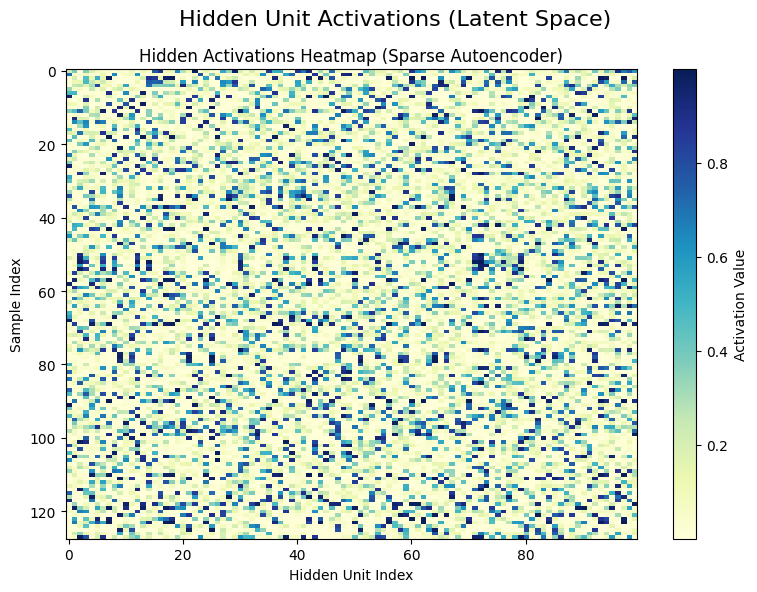

In [411]:
# Visualize both autoencoders
print("Naive Autoencoder Results:")
print_ae_results(naive_model, train_dataloader, "naive")

print("\nSparse Autoencoder Results:")
print_ae_results(sparse_model, train_dataloader, "sparse")

#### Note:

**Since the graph in question 3 is a superset of the graph in question 2, see the plot in the next question to avoid code duplication.**

---

#### Question 3: A Shallow NN

A simple shallow NN model with 1 hidden layer of size 100. Uses Sigmoid activation, cross entropy loss, and SGD optimizer.

In [412]:
class ShallowNN(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = torch.nn.Flatten()
    self.linear = torch.nn.Sequential(
      torch.nn.Linear(28*28, 100),
      torch.nn.Sigmoid(),
      torch.nn.Linear(100, 10)
    )
    
  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear(x)
    return logits

model = ShallowNN().to(device)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1, momentum=0.9)

Altered the architecture of the above class to support providing pre-trained weights which don't need to be updated during training. 

Uses Sigmoid as the non-linear activation, and optimizes using SGD. SGD was tried, but resulted in poor training results for the sparse results, and Adam was used for better results. SGD also used momentum to help with convergence.

In [413]:
class FixedFirstLayerNN(torch.nn.Module):
  def __init__(self, encoder_linear):
    super().__init__()
    self.flatten = torch.nn.Flatten()
    self.encoder = torch.nn.Linear(28*28, 100)
    self.encoder.weight = torch.nn.Parameter(encoder_linear.weight.data.clone(), requires_grad=False)
    self.encoder.bias = torch.nn.Parameter(encoder_linear.bias.data.clone(), requires_grad=False)
    self.activation = torch.nn.Sigmoid()
    self.fc2 = torch.nn.Linear(100, 10)

  def forward(self, x):
    x = self.flatten(x)
    x = self.encoder(x)
    x = self.activation(x)
    x = self.fc2(x)
    return x
    
naive_encoder_linear = naive_model.encoder[0]
sparse_encoder_linear = sparse_model.encoder[0]

fixed_naive_nn = FixedFirstLayerNN(naive_encoder_linear).to(device)
fixed_sparse_nn = FixedFirstLayerNN(sparse_encoder_linear).to(device)

optimizer_naive = torch.optim.SGD(fixed_naive_nn.fc2.parameters(), lr=1e-1, momentum=0.9)
optimizer_sparse = torch.optim.Adam(fixed_sparse_nn.fc2.parameters(), lr=0.2)

Trains the simple NN, and the fixed weight autoencoder based NNs (sparse and naive) with 200 epochs and saves the test accuracy for each epoch

In [414]:
test_accuracies_NN = []
test_accuracies_naive = []
test_accuracies_sparse = []

epochs = 200
for t in range(epochs):
  train_direct(X_train, y_train, model, loss_fn, optimizer)
  acc = test_direct(X_test, y_test, model, loss_fn)
  test_accuracies_NN.append(acc)

  train_direct(X_train, y_train, fixed_naive_nn, loss_fn, optimizer_naive)
  acc_naive = test_direct(X_test, y_test, fixed_naive_nn, loss_fn)
  test_accuracies_naive.append(acc_naive)
  
  train_direct(X_train, y_train, fixed_sparse_nn, loss_fn, optimizer_sparse)
  acc_sparse = test_direct(X_test, y_test, fixed_sparse_nn, loss_fn)
  test_accuracies_sparse.append(acc_sparse)
  
  if t % 10 == 0:
    print(f"Epoch {t+1}, Accuracies: {test_accuracies_NN[-1]}, {test_accuracies_naive[-1]}, {test_accuracies_sparse[-1]}")

Epoch 1, Accuracies: 0.1013, 0.1322, 0.645
Epoch 11, Accuracies: 0.7411, 0.7641, 0.8366
Epoch 21, Accuracies: 0.8413, 0.826, 0.8753
Epoch 31, Accuracies: 0.8742, 0.8427, 0.8975
Epoch 41, Accuracies: 0.8911, 0.8529, 0.9072
Epoch 51, Accuracies: 0.9017, 0.8593, 0.9134
Epoch 61, Accuracies: 0.9087, 0.8647, 0.9174
Epoch 71, Accuracies: 0.9152, 0.8673, 0.9196
Epoch 81, Accuracies: 0.9192, 0.8704, 0.9213
Epoch 91, Accuracies: 0.9233, 0.8723, 0.9233
Epoch 101, Accuracies: 0.9253, 0.8744, 0.9233
Epoch 111, Accuracies: 0.9261, 0.876, 0.9242
Epoch 121, Accuracies: 0.9279, 0.8772, 0.9245
Epoch 131, Accuracies: 0.9293, 0.8781, 0.9251
Epoch 141, Accuracies: 0.9305, 0.879, 0.9258
Epoch 151, Accuracies: 0.9328, 0.8799, 0.9262
Epoch 161, Accuracies: 0.9355, 0.8813, 0.9271
Epoch 171, Accuracies: 0.937, 0.8821, 0.9275
Epoch 181, Accuracies: 0.9375, 0.8826, 0.9276
Epoch 191, Accuracies: 0.9391, 0.8836, 0.9278


Replicates the figure in M02-S14: with the simple NN coming out on top, followed by the sparse NN, the softmax regression, and finally the naive NN. 

This shows the effectiveness of using a more structured latent space in the sparse autoencoder, as well as the costs of learning poor representations in the naive autoencoder.

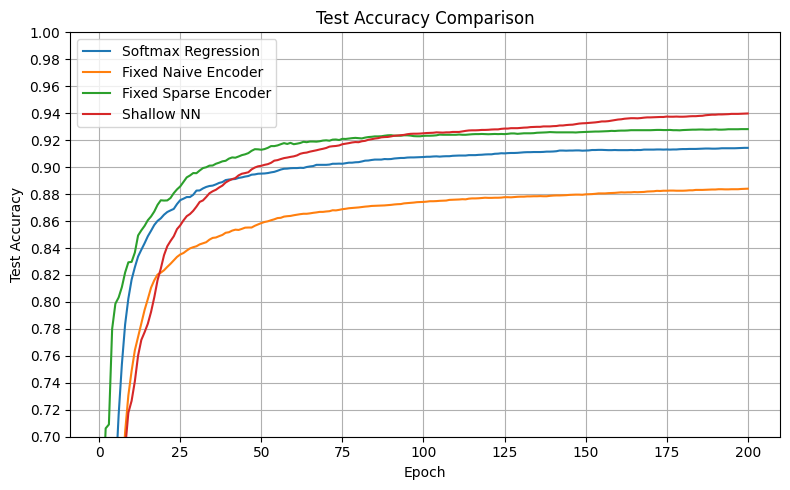

In [415]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(test_accuracies)+1), test_accuracies, label="Softmax Regression")
plt.plot(range(1, len(test_accuracies_naive)+1), test_accuracies_naive, label="Fixed Naive Encoder")
plt.plot(range(1, len(test_accuracies_sparse)+1), test_accuracies_sparse, label="Fixed Sparse Encoder")
plt.plot(range(1, len(test_accuracies_NN)+1), test_accuracies_NN, label="Shallow NN")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.ylim(0.7, 1.0)
plt.yticks(np.arange(0.7, 1.01, 0.02))
plt.tight_layout()
plt.show()

---

#### Question 4: Full BP on Both Layers

In [422]:
class PreInitFirstLayerNN(torch.nn.Module):
  def __init__(self, encoder_linear):
    super().__init__()
    self.flatten = torch.nn.Flatten()
    self.encoder = torch.nn.Linear(28*28, 100)
    self.encoder.weight = torch.nn.Parameter(encoder_linear.weight.data.clone())
    self.encoder.bias = torch.nn.Parameter(encoder_linear.bias.data.clone())
    self.activation = torch.nn.Sigmoid()
    self.fc2 = torch.nn.Linear(100, 10)

  def forward(self, x):
    x = self.flatten(x)
    x = self.encoder(x)
    x = self.activation(x)
    x = self.fc2(x)
    return x

preinit_naive_nn = PreInitFirstLayerNN(naive_encoder_linear).to(device)
preinit_sparse_nn = PreInitFirstLayerNN(sparse_encoder_linear).to(device)

pn_optimizer = torch.optim.SGD(preinit_naive_nn.parameters(), lr=0.01, momentum=0.9)
ps_optimizer = torch.optim.SGD(preinit_sparse_nn.parameters(), lr=0.01, momentum=0.8)

pn_optimizer = torch.optim.SGD(preinit_naive_nn.parameters(), lr=1e-1, momentum=0.9)
ps_optimizer = torch.optim.Adam(preinit_sparse_nn.parameters(), lr=0.2)

In [423]:
test_accuracies_naive_PINN = []
test_accuracies_sparse_PINN = []

epochs = 200
for t in range(epochs):
  if t % 10 == 0:
    print(f"Epoch {t+1}")
  train_direct(X_train, y_train, preinit_naive_nn, loss_fn, pn_optimizer)
  acc = test_direct(X_test, y_test, preinit_naive_nn, loss_fn)
  test_accuracies_naive_PINN.append(acc)

  train_direct(X_train, y_train, preinit_sparse_nn, loss_fn, ps_optimizer)
  acc = test_direct(X_test, y_test, preinit_sparse_nn, loss_fn)
  test_accuracies_sparse_PINN.append(acc)

Epoch 1
Epoch 11
Epoch 21
Epoch 31
Epoch 41
Epoch 51
Epoch 61
Epoch 71
Epoch 81
Epoch 91
Epoch 101
Epoch 111
Epoch 121
Epoch 131
Epoch 141
Epoch 151
Epoch 161
Epoch 171
Epoch 181
Epoch 191


Plot which mimics the behavior of M02-S17 as the autoencoder versions all come up to around the same accuracy (at least above their original and above softmax) showing that the pre-initialization steps can be unnecessary if both layers are allowed to be trained

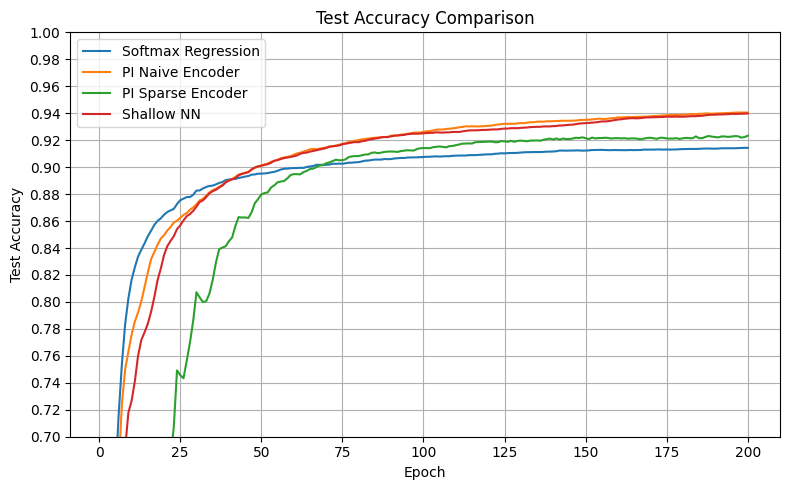

In [424]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(test_accuracies)+1), test_accuracies, label="Softmax Regression")
plt.plot(range(1, len(test_accuracies_naive)+1), test_accuracies_naive_PINN, label="PI Naive Encoder")
plt.plot(range(1, len(test_accuracies_sparse)+1), test_accuracies_sparse_PINN, label="PI Sparse Encoder")
plt.plot(range(1, len(test_accuracies_NN)+1), test_accuracies_NN, label="Shallow NN")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.ylim(0.7, 1.0)
plt.yticks(np.arange(0.7, 1.01, 0.02))
plt.tight_layout()
plt.show()

#### Question 4 Part 2:

Created a template NN class which can take in different activation functions and weight initialization schemes. 
Tested 3 different initialization schemes (normal, xavier, and kaiming) with both Sigmoid and ReLU activation functions.

In [482]:
class TemplateNN(torch.nn.Module):
  def __init__(self, activation_fn=torch.nn.ReLU(), initialization='normal'):
    super().__init__()
    self.flatten = torch.nn.Flatten()
    self.linear = torch.nn.Sequential(
      torch.nn.Linear(28*28, 512),
      activation_fn,
      torch.nn.Linear(512, 512),
      activation_fn,
      torch.nn.Linear(512, 512),
      activation_fn,
      torch.nn.Linear(512, 512),
      activation_fn,
      torch.nn.Linear(512, 512),
      activation_fn,
      torch.nn.Linear(512, 10)
    )
    
    if initialization == 'normal':
      for layer in self.linear:
        if isinstance(layer, torch.nn.Linear):
          torch.nn.init.normal_(layer.weight, mean=0.0, std=0.01)
    if initialization == 'xavier':
      for layer in self.linear:
        if isinstance(layer, torch.nn.Linear):
          torch.nn.init.xavier_normal_(layer.weight)
    if initialization == 'kaiming':
      for layer in self.linear:
        if isinstance(layer, torch.nn.Linear):
          torch.nn.init.kaiming_normal_(layer.weight, nonlinearity='leaky_relu')
  
  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear(x)
    return logits

Setup the model parameters and training details. 

Used SGD for all but wasn't able to get the relu_normal to converge w/o batch normalization.

In [545]:
sigmoid_normal_model = TemplateNN(activation_fn=torch.nn.Sigmoid(), initialization='normal').to(device)
sigmoid_xavier_model = TemplateNN(activation_fn=torch.nn.Sigmoid(), initialization='xavier').to(device)
relu_normal_model = TemplateNN(activation_fn=torch.nn.ReLU(), initialization='normal').to(device)
relu_xavier_model = TemplateNN(activation_fn=torch.nn.ReLU(), initialization='xavier').to(device)
relu_kaiming_model = TemplateNN(activation_fn=torch.nn.ReLU(), initialization='kaiming').to(device)

models = {
    "Sigmoid Normal": sigmoid_normal_model,
    "Sigmoid Xavier": sigmoid_xavier_model,
    "ReLU Normal": relu_normal_model,
    "ReLU Xavier": relu_xavier_model,
    "ReLU Kaiming": relu_kaiming_model
}

loss_fn = torch.nn.CrossEntropyLoss()

optimizers = {
    "Sigmoid Normal": torch.optim.SGD(sigmoid_normal_model.parameters(), lr=0.7),
    "Sigmoid Xavier": torch.optim.SGD(sigmoid_xavier_model.parameters(), lr=0.7),
    "ReLU Normal": torch.optim.SGD(relu_normal_model.parameters(), lr=5e-2, momentum=0.9),
    "ReLU Xavier": torch.optim.SGD(relu_xavier_model.parameters(), lr=3e-2),
    "ReLU Kaiming": torch.optim.SGD(relu_kaiming_model.parameters(), lr=2e-2)
}

test_accuracies_dict = {name: [] for name in models.keys()}

In [548]:
epochs = 50
for t in range(epochs):
  if t % 5 == 0:
    print(f"Epoch {t+1}")
  for name, model in models.items():
    optimizer = optimizers[name]
    train_direct(X_train, y_train, model, loss_fn, optimizer)
    acc = test_direct(X_test, y_test, model, loss_fn)
    test_accuracies_dict[name].append(acc)

Epoch 1
Epoch 6
Epoch 11
Epoch 16
Epoch 21
Epoch 26
Epoch 31
Epoch 36
Epoch 41
Epoch 46


Plot showing the test accuracy for full batch training of the 5 different models. 

The 2 ReLU models with initialization schemes perform the best yet the rest don't converge and stay at random chance levels.

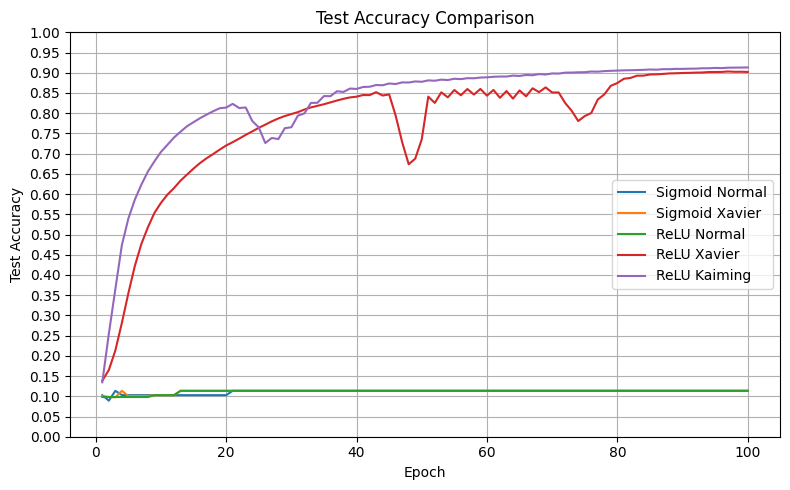

In [549]:
plt.figure(figsize=(8, 5))
for name, accuracies in test_accuracies_dict.items():
    plt.plot(range(1, len(accuracies)+1), accuracies, label=name)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.ylim(0.0, 1.0)
plt.yticks(np.arange(0.0, 1.01, 0.05))
plt.tight_layout()
plt.show()

In [ ]:


epochs = 50
batch_accuracies = {name: [] for name in models.keys()}
for t in range(epochs):
  if t % 5 == 0:
    print(f"Epoch {t+1}")
  for name, model in models.items():
    optimizer = optimizers[name]
    train(train_dataloader, model, loss_fn, optimizer)
    acc = test(test_dataloader, model, loss_fn)
    batch_accuracies[name].append(acc)

Epoch 1
Epoch 6
Epoch 11
Epoch 16
Epoch 21
Epoch 26
Epoch 31
Epoch 36
Epoch 41
Epoch 46


Now we do the training with batch normalization and as expected the models all converge and perform well with some models converging slightly faster than others but all ended up with approximately the same final accuracy.

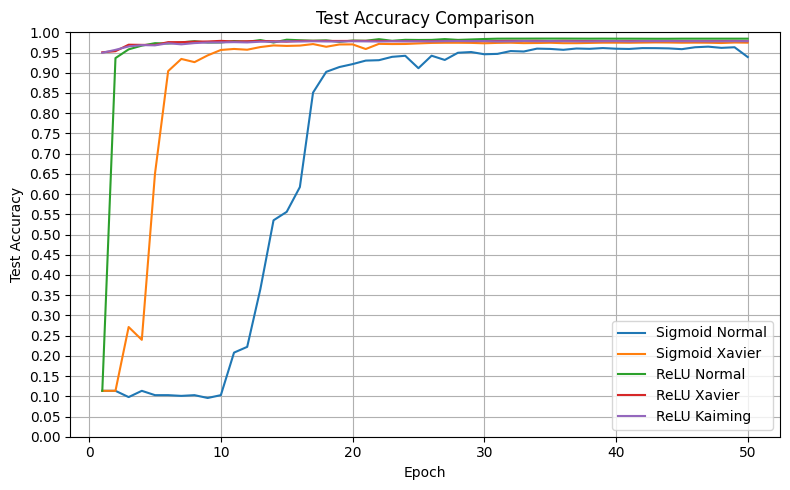

In [551]:
plt.figure(figsize=(8, 5))
for name, accuracies in batch_accuracies.items():
    plt.plot(range(1, len(accuracies)+1), accuracies, label=name)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.ylim(0.0, 1.0)
plt.yticks(np.arange(0.0, 1.01, 0.05))
plt.tight_layout()
plt.show()